# Pattern feature

In [145]:
import datetime
import os
import shutil
import sys
import time

import numpy as np
import path
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import sys

from pathlib import Path
from collections import Counter
from utils import *

parent_dir = Path.cwd().parent.resolve()

if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

from data import data
from logger import get_logger
from prepare import accuracy, fetch_data, initialise

In [121]:
from argparse import Namespace

args = Namespace(
    data="coauthorship",
    dataset="dblp",
    model_name="UniGCNII",
    first_aggregate="mean",
    second_aggregate="sum",
    add_self_loop=False,
    use_norm=False,
    activation="relu",
    nlayer=64,
    nhid=8,
    nhead=8,
    dropout=0.6,
    input_drop=0.6,
    attn_drop=0.6,
    lr=0.01,
    wd=5e-4,
    epochs=1000,
    n_runs=10,
    gpu=0,
    seed=1,
    patience=150,
    nostdout=False,
    split=1,
    out_dir="runs/elbow_labeled",
)

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Override configuration values here when needed, for example:
# args.epochs = 200
# args.n_runs = 10

torch.manual_seed(args.seed)
np.random.seed(args.seed)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = str(args.gpu)
os.environ["PYTHONHASHSEED"] = str(args.seed)

dataname = f"{args.data}_{args.dataset}"
out_dir = path.Path(
    f"./{args.out_dir}/{args.model_name}_{args.nlayer}_{dataname}/seed_{args.seed}"
)

if out_dir.exists():
    shutil.rmtree(out_dir)
out_dir.makedirs_p()

baselogger = get_logger("base logger", f"{out_dir}/logging.log", not args.nostdout)
resultlogger = get_logger("result logger", f"{out_dir}/result.log", not args.nostdout)
baselogger.info(args)
resultlogger.info(args)

Namespace(data='coauthorship', dataset='dblp', model_name='UniGCNII', first_aggregate='mean', second_aggregate='sum', add_self_loop=False, use_norm=False, activation='relu', nlayer=64, nhid=8, nhead=8, dropout=0.6, input_drop=0.6, attn_drop=0.6, lr=0.01, wd=0.0005, epochs=200, n_runs=10, gpu=0, seed=1, patience=200, nostdout=False, split=1, out_dir='runs/elbow_labeled')
Namespace(data='coauthorship', dataset='dblp', model_name='UniGCNII', first_aggregate='mean', second_aggregate='sum', add_self_loop=False, use_norm=False, activation='relu', nlayer=64, nhid=8, nhead=8, dropout=0.6, input_drop=0.6, attn_drop=0.6, lr=0.01, wd=0.0005, epochs=200, n_runs=10, gpu=0, seed=1, patience=200, nostdout=False, split=1, out_dir='runs/elbow_labeled')
Namespace(data='coauthorship', dataset='dblp', model_name='UniGCNII', first_aggregate='mean', second_aggregate='sum', add_self_loop=False, use_norm=False, activation='relu', nlayer=64, nhid=8, nhead=8, dropout=0.6, input_drop=0.6, attn_drop=0.6, lr=0.01,

## Filter out patterns of a frequency threshold - Training with labeled simplets

In [62]:
from utils import *

In [63]:
dataset_directory = "../data/coauthorship/dblp"
dataset = load_data(dataset_directory)

feature_matrix, patterns, frequencies = build_feature_matrix(
    data=dataset,
    pattern_file="/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12",
    image_file="/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12occMap",
    min_frequency=200,
)

print(feature_matrix.shape)
print(frequencies)

number of hyperedges is 22363
(41302, 69)
[3868.0, 3127.0, 2603.0, 2304.0, 2082.0, 1855.0, 1603.0, 1578.0, 1503.0, 1387.0, 1368.0, 1294.0, 1288.0, 1103.0, 997.0, 962.0, 945.0, 889.0, 878.0, 839.0, 835.0, 833.0, 702.0, 691.0, 677.0, 661.0, 634.0, 589.0, 585.0, 583.0, 564.0, 526.0, 522.0, 516.0, 472.0, 463.0, 461.0, 448.0, 410.0, 406.0, 405.0, 395.0, 394.0, 385.0, 369.0, 363.0, 338.0, 336.0, 332.0, 329.0, 323.0, 320.0, 310.0, 306.0, 299.0, 293.0, 289.0, 281.0, 272.0, 252.0, 251.0, 240.0, 235.0, 232.0, 231.0, 230.0, 218.0, 218.0, 209.0]


In [19]:
frequency_interval = list(np.arange(100, 2100, 100))
_, Y, G = fetch_data(args)
Y = Y.to(device)

experiment_results = []

for threshold in frequency_interval:
    result, _ = train_for_threshold(
        threshold=threshold,
        Y=Y,
        G=G,
        pattern_file = "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12",
        image_file = "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12occMap",
        args=args,
    )

    experiment_results.append(result)

    print(
        f"Completed threshold {threshold}: "
        f"{result['number_of_patterns']} patterns, "
        f"mean accuracy "
        f"{result['mean_final_train_accuracy']:.4f}"
    )

number of hyperedges is 22363
[0. 1. 2. ... 1. 1. 3.]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
number of hyperedges is 22363
threshold=100, run=1/10, patterns=137, train=90.0575, test=90.9989, best test=91.0596, time=42.18s
number of hyperedges is 22363
threshold=100, run=2/10, patterns=137, train=91.6092, test=91.0520, best test=91.0849, time=42.24s
number of hyperedges is 22363
threshold=100, run=3/10, patterns=137, train=91.6092, test=90.9914, best test=91.0773, time=42.29s
number of hyperedges is 22363
threshold=100, run=4/10, patterns=137, train=90.4023, test=91.2062, best test=91.2441, time=42.44s
number of hyperedges is 22363
threshold=100, run=5/10, patterns=137, train=91.6667, test=90.9408, best test=90.9686, time=42.58s
number of hyperedges is 22363
threshold=100, run=6/10, patterns=137, train=91.6667, test=90.8498, best test=90.8599, time=42.59s
number of hypere

In [31]:
import pandas as pd

results_df = pd.DataFrame(experiment_results)
results_df.to_csv(
    "frequency_training_results.csv",
    index=False,
)

results_df

,threshold,number_of_patterns,mean_final_train_accuracy,std_final_train_accuracy,mean_epoch_train_accuracy,mean_final_test_accuracy,std_final_test_accuracy,mean_best_test_accuracy,std_best_test_accuracy
0,100,137,91.270115,0.716643,90.152212,91.027753,0.092715,91.074262,0.099321
1,200,69,90.936781,0.696352,89.784913,90.992618,0.086418,91.053282,0.075258
2,300,54,90.954022,0.665874,89.641982,90.982760,0.066620,91.050501,0.061628
3,400,41,90.804597,0.647668,89.614051,90.878619,0.078936,90.998937,0.040805
4,500,34,90.793104,0.638837,89.474626,90.918052,0.063576,90.987563,0.041860
5,600,27,90.632184,0.485625,89.027729,90.838935,0.076394,90.914260,0.048016
6,700,23,90.534483,0.626437,88.898390,90.790657,0.026563,90.871543,0.049172
7,800,22,90.448276,0.593264,88.928649,90.769929,0.033671,90.854354,0.052826
8,900,17,89.885057,0.531726,87.819109,90.416054,0.066313,90.484049,0.060897
9,1000,14,89.804597,0.612656,87.635229,90.331630,0.075865,90.382943,0.085868


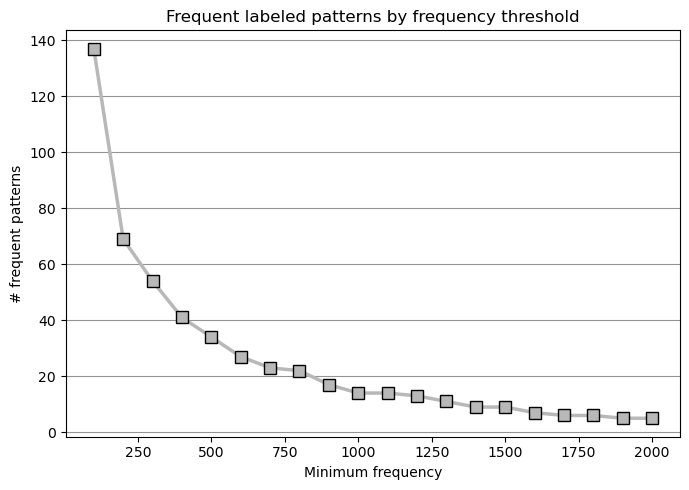

In [51]:
import matplotlib.pyplot as plt
thresholds = results_df["threshold"].to_numpy()
pattern_counts = results_df["number_of_patterns"].to_numpy()

plt.figure(figsize=(7, 5))

plt.plot(
    thresholds,
    pattern_counts,
    color="#b8b8b8",
    linewidth=2.5,
    marker="s",
    markersize=8,
    markerfacecolor="#b8b8b8",
    markeredgecolor="black",
)

plt.xlabel("Minimum frequency")
plt.ylabel("# frequent patterns")
plt.title("Frequent labeled patterns by frequency threshold")
plt.grid(axis="y", color="#666666", alpha=0.7)
plt.tight_layout()
plt.savefig("number_of_patterns_by_frequency.png", dpi=600)
plt.show()

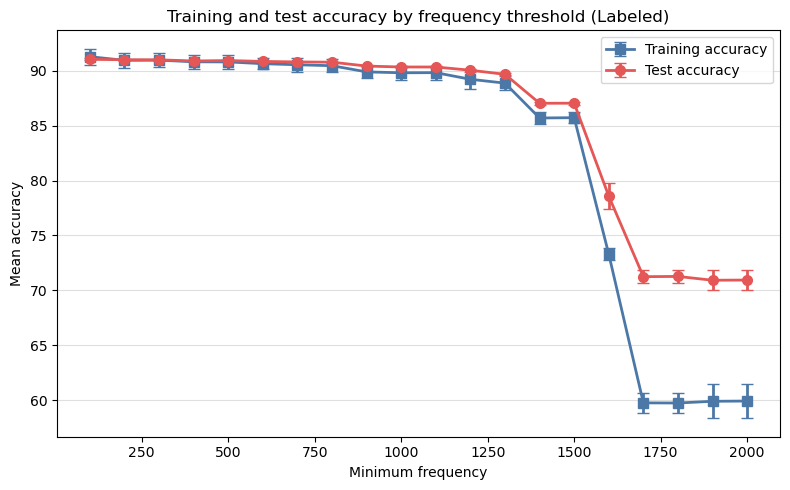

In [55]:
thresholds = results_df["threshold"].to_numpy()

mean_train = results_df[
    "mean_final_train_accuracy"
].to_numpy()
std_train = results_df[
    "std_final_train_accuracy"
].to_numpy()

mean_test = results_df[
    "mean_final_test_accuracy"
].to_numpy()
std_test = results_df[
    "std_final_test_accuracy"
].to_numpy()

plt.figure(figsize=(8, 5))

plt.errorbar(
    thresholds,
    mean_train,
    yerr=std_train,
    color="#4C78A8",
    marker="s",
    linewidth=2,
    markersize=7,
    capsize=4,
    label="Training accuracy",
)

plt.errorbar(
    thresholds,
    mean_test,
    yerr=std_test,
    color="#E45756",
    marker="o",
    linewidth=2,
    markersize=7,
    capsize=4,
    label="Test accuracy",
)

plt.xlabel("Minimum frequency")
plt.ylabel("Mean accuracy")
plt.title("Training and test accuracy by frequency threshold (Labeled)")
plt.grid(axis="y", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig(
    "training_test_accuracy_by_frequency.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Running unlabeled simplets

In [66]:
frequency_interval = list(np.arange(100, 2100, 100))
experiment_results_unlabeled = []
_, Y, G = fetch_data(args)
Y = Y.to(device)

for threshold in frequency_interval:
    result, _ = train_for_threshold(
        threshold=threshold,
        Y=Y,
        G=G,
        pattern_file = "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/dblp_uniGNN_old_unlabeld_simplices_PLMSC/rerun1/dblp_uniGNN_old_unlabeld_simplices_PLMSC_freq_100_minDim_0_maxSize_12",
        image_file = "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/dblp_uniGNN_old_unlabeld_simplices_PLMSC/rerun1/dblp_uniGNN_old_unlabeld_simplices_PLMSC_freq_100_minDim_0_maxSize_12occMap",
        args=args,
    )

    experiment_results_unlabeled.append(result)

    print(
        f"Completed threshold {threshold}: "
        f"{result['number_of_patterns']} patterns, "
        f"mean accuracy "
        f"{result['mean_final_train_accuracy']:.4f}"
    )

number of hyperedges is 22363
[0. 1. 2. ... 1. 1. 3.]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
number of hyperedges is 22363
threshold=100, run=1/10, patterns=272, train=55.8621, test=41.8508, best test=42.5737, time=42.19s
number of hyperedges is 22363
threshold=100, run=2/10, patterns=272, train=55.8046, test=42.2451, best test=43.2688, time=42.18s
number of hyperedges is 22363
threshold=100, run=3/10, patterns=272, train=58.1609, test=43.5468, best test=44.3961, time=42.32s
number of hyperedges is 22363
threshold=100, run=4/10, patterns=272, train=55.5747, test=39.2321, best test=39.9803, time=42.36s
number of hyperedges is 22363
threshold=100, run=5/10, patterns=272, train=57.0115, test=39.5961, best test=39.5961, time=42.56s
number of hyperedges is 22363
threshold=100, run=6/10, patterns=272, train=53.5057, test=36.6791, best test=38.5799, time=42.56s
number of hypere

In [68]:
results_df_unlabeled = pd.DataFrame(experiment_results_unlabeled)
results_df_unlabeled.to_csv(
    "frequency_training_results_unlabeled.csv",
    index=False,
)

results_df_unlabeled

,threshold,number_of_patterns,mean_final_train_accuracy,std_final_train_accuracy,mean_epoch_train_accuracy,mean_final_test_accuracy,std_final_test_accuracy,mean_best_test_accuracy,std_best_test_accuracy
0,100,272,55.425287,1.419948,51.116322,40.188312,2.174339,40.954451,1.999512
1,200,111,40.603448,0.932825,38.546925,30.813154,1.750611,32.661392,1.234978
2,300,64,35.316092,0.746795,33.853190,27.635104,1.485632,30.350842,1.437401
3,400,45,32.689655,0.694333,31.560517,26.066933,0.491646,28.819827,1.293299
4,500,34,31.080460,0.804926,30.348506,24.689853,0.930288,27.322936,1.960138
5,600,28,30.534483,0.823284,29.832155,24.463626,0.632013,29.227036,1.796109
6,700,24,30.247127,0.693500,29.411350,24.276831,0.942378,28.716445,1.593295
7,800,21,30.189655,0.541604,29.349684,24.388302,0.807419,28.417168,2.634943
8,900,18,29.781609,0.883937,28.954138,23.977301,1.084172,28.114605,2.367367
9,1000,17,29.545977,0.435001,28.779080,23.665133,0.810933,27.195288,2.004496


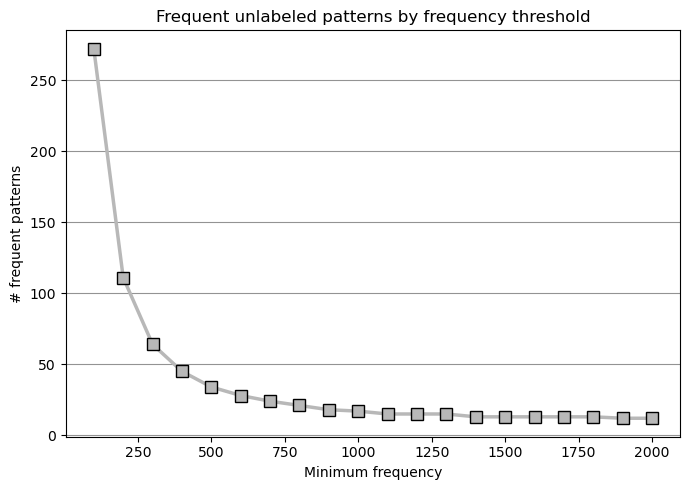

In [69]:
thresholds = results_df_unlabeled["threshold"].to_numpy()
pattern_counts = results_df_unlabeled["number_of_patterns"].to_numpy()

plt.figure(figsize=(7, 5))

plt.plot(
    thresholds,
    pattern_counts,
    color="#b8b8b8",
    linewidth=2.5,
    marker="s",
    markersize=8,
    markerfacecolor="#b8b8b8",
    markeredgecolor="black",
)

plt.xlabel("Minimum frequency")
plt.ylabel("# frequent patterns")
plt.title("Frequent unlabeled patterns by frequency threshold")
plt.grid(axis="y", color="#666666", alpha=0.7)
plt.tight_layout()
plt.savefig("number_of_patterns_by_frequency_unlabeled.png", dpi=600)
plt.show()

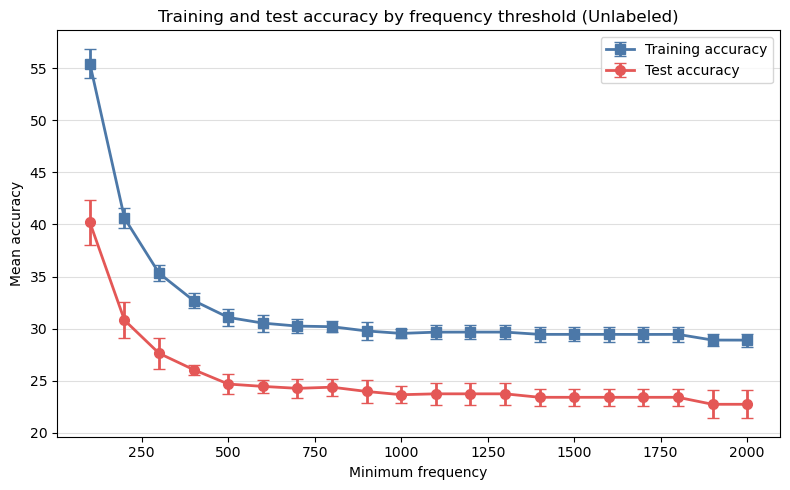

In [70]:
thresholds = results_df_unlabeled["threshold"].to_numpy()

mean_train = results_df_unlabeled[
    "mean_final_train_accuracy"
].to_numpy()
std_train = results_df_unlabeled[
    "std_final_train_accuracy"
].to_numpy()

mean_test = results_df_unlabeled[
    "mean_final_test_accuracy"
].to_numpy()
std_test = results_df_unlabeled[
    "std_final_test_accuracy"
].to_numpy()

plt.figure(figsize=(8, 5))

plt.errorbar(
    thresholds,
    mean_train,
    yerr=std_train,
    color="#4C78A8",
    marker="s",
    linewidth=2,
    markersize=7,
    capsize=4,
    label="Training accuracy",
)

plt.errorbar(
    thresholds,
    mean_test,
    yerr=std_test,
    color="#E45756",
    marker="o",
    linewidth=2,
    markersize=7,
    capsize=4,
    label="Test accuracy",
)

plt.xlabel("Minimum frequency")
plt.ylabel("Mean accuracy")
plt.title("Training and test accuracy by frequency threshold (Unlabeled)")
plt.grid(axis="y", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig(
    "training_test_accuracy_by_frequency_unlabeled.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

## Shuffling labels

In [76]:
frequency_interval = list(np.arange(100, 1001, 100))
experiment_results_random = []
_, Y, G = fetch_data(args)
Y = Y.to(device)

for threshold in frequency_interval:
    result, _ = train_for_threshold(
        threshold=threshold,
        Y=Y,
        G=G,
        pattern_file = "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/AMiner_randomly_permutate_vertex_label/AMiner_randomly_permutate_vertex_label_freq_10_minDim_0_maxSize_12",
        image_file = "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/AMiner_randomly_permutate_vertex_label/AMiner_randomly_permutate_vertex_label_freq_10_minDim_0_maxSize_12occMap",
        args=args,
    )

    experiment_results_random.append(result)

    print(
        f"Completed threshold {threshold}: "
        f"{result['number_of_patterns']} patterns, "
        f"mean accuracy "
        f"{result['mean_final_train_accuracy']:.4f}"
    )

number of hyperedges is 22363
[0. 1. 2. ... 1. 1. 3.]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


/data/cs.aau.dk/tungkvt/Nhi/UniGNN/prepare.py:138: RuntimeWarning: divide by zero encountered in power
  di = np.power(d, -1).flatten()


number of hyperedges is 22363
threshold=100, run=1/10, patterns=37, train=29.1379, test=22.0262, best test=29.5182, time=42.11s
number of hyperedges is 22363
threshold=100, run=2/10, patterns=37, train=26.3793, test=21.2729, best test=29.0304, time=42.18s
number of hyperedges is 22363
threshold=100, run=3/10, patterns=37, train=27.8736, test=22.3320, best test=25.8152, time=42.21s
number of hyperedges is 22363
threshold=100, run=4/10, patterns=37, train=27.4138, test=23.0069, best test=30.2740, time=42.30s
number of hyperedges is 22363
threshold=100, run=5/10, patterns=37, train=27.4713, test=21.6192, best test=28.1583, time=42.51s
number of hyperedges is 22363
threshold=100, run=6/10, patterns=37, train=27.7586, test=21.6395, best test=30.3473, time=42.53s
number of hyperedges is 22363
threshold=100, run=7/10, patterns=37, train=28.2759, test=21.9605, best test=27.3823, time=42.55s
number of hyperedges is 22363
threshold=100, run=8/10, patterns=37, train=26.8966, test=21.5308, best te

In [82]:
results_df_random = pd.DataFrame(experiment_results_random)
results_df_random.to_csv(
    "frequency_training_results_random.csv",
    index=False,
)

results_df

,threshold,number_of_patterns,mean_final_train_accuracy,std_final_train_accuracy,mean_epoch_train_accuracy,mean_final_test_accuracy,std_final_test_accuracy,mean_best_test_accuracy,std_best_test_accuracy
0,100,137,91.270115,0.716643,90.152212,91.027753,0.092715,91.074262,0.099321
1,200,69,90.936781,0.696352,89.784913,90.992618,0.086418,91.053282,0.075258
2,300,54,90.954022,0.665874,89.641982,90.982760,0.066620,91.050501,0.061628
3,400,41,90.804597,0.647668,89.614051,90.878619,0.078936,90.998937,0.040805
4,500,34,90.793104,0.638837,89.474626,90.918052,0.063576,90.987563,0.041860
5,600,27,90.632184,0.485625,89.027729,90.838935,0.076394,90.914260,0.048016
6,700,23,90.534483,0.626437,88.898390,90.790657,0.026563,90.871543,0.049172
7,800,22,90.448276,0.593264,88.928649,90.769929,0.033671,90.854354,0.052826
8,900,17,89.885057,0.531726,87.819109,90.416054,0.066313,90.484049,0.060897
9,1000,14,89.804597,0.612656,87.635229,90.331630,0.075865,90.382943,0.085868


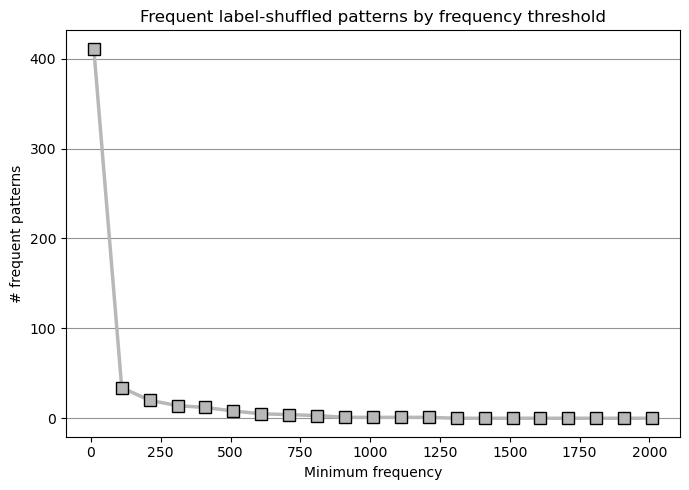

In [56]:
# import matplotlib.pyplot as plt
thresholds = results_df_random["threshold"].to_numpy()
pattern_counts = results_df_random["number_of_patterns"].to_numpy()

plt.figure(figsize=(7, 5))

plt.plot(
    thresholds,
    pattern_counts,
    color="#b8b8b8",
    linewidth=2.5,
    marker="s",
    markersize=8,
    markerfacecolor="#b8b8b8",
    markeredgecolor="black",
)

plt.xlabel("Minimum frequency")
plt.ylabel("# frequent patterns")
plt.title("Frequent label-shuffled patterns by frequency threshold")
plt.grid(axis="y", color="#666666", alpha=0.7)
plt.tight_layout()
plt.savefig("number_of_patterns_random_by_frequency.png", dpi=300)
plt.show()

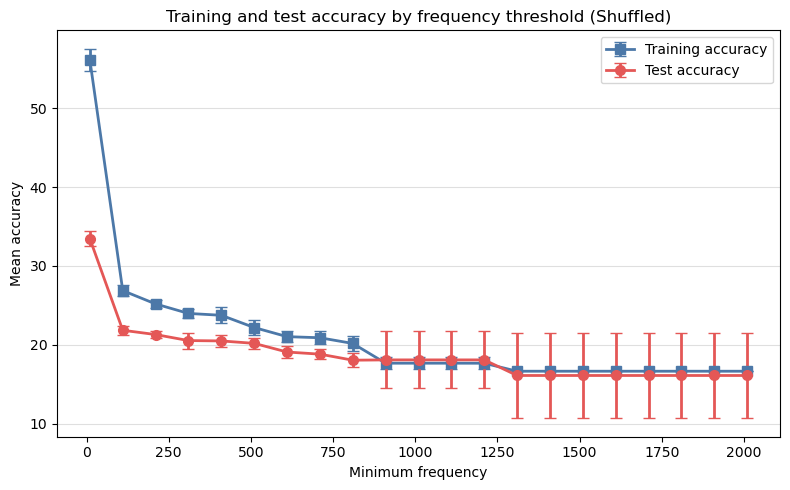

In [57]:
thresholds = results_df_random["threshold"].to_numpy()

mean_train = results_df_random[
    "mean_final_train_accuracy"
].to_numpy()
std_train = results_df_random[
    "std_final_train_accuracy"
].to_numpy()

mean_test = results_df_random[
    "mean_final_test_accuracy"
].to_numpy()
std_test = results_df_random[
    "std_final_test_accuracy"
].to_numpy()

plt.figure(figsize=(8, 5))

plt.errorbar(
    thresholds,
    mean_train,
    yerr=std_train,
    color="#4C78A8",
    marker="s",
    linewidth=2,
    markersize=7,
    capsize=4,
    label="Training accuracy",
)

plt.errorbar(
    thresholds,
    mean_test,
    yerr=std_test,
    color="#E45756",
    marker="o",
    linewidth=2,
    markersize=7,
    capsize=4,
    label="Test accuracy",
)

plt.xlabel("Minimum frequency")
plt.ylabel("Mean accuracy")
plt.title("Training and test accuracy by frequency threshold (Shuffled)")
plt.grid(axis="y", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig(
    "training_test_accuracy_by_frequency_random.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## t-SNE

Using 2000 sampled vertices for t-SNE
SVD dimensions: 137 -> 50; explained variance: 0.788
Saved plot to t-SNE-labeled.pdf


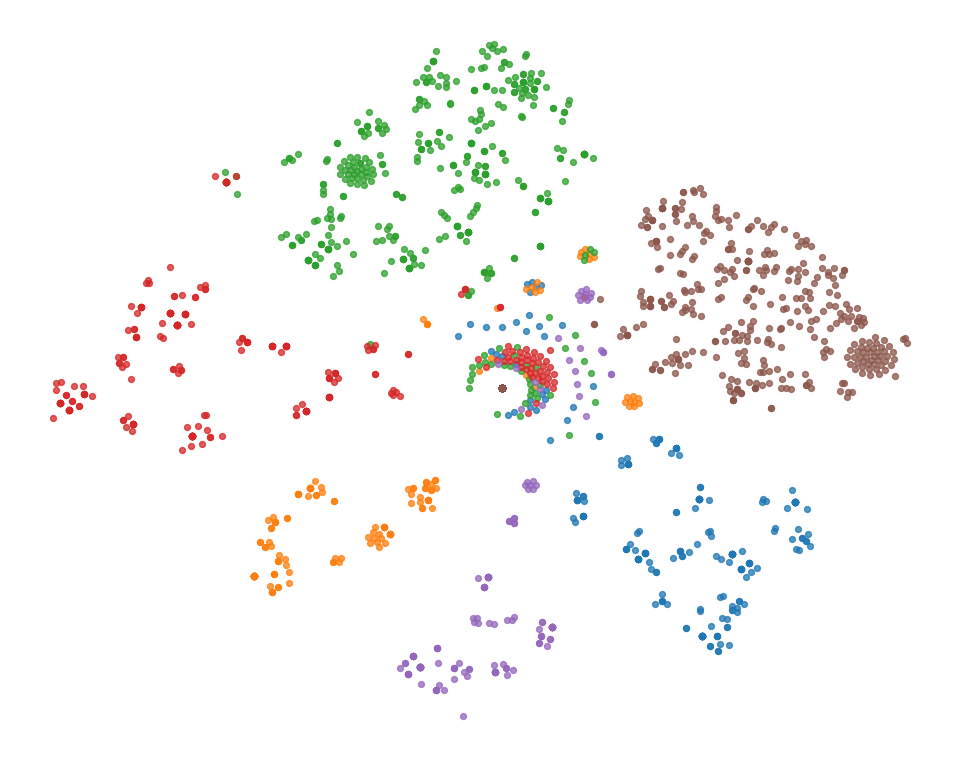

(array([[  4.064186  ,   3.9308796 ],
        [-68.761826  ,  11.546007  ],
        [  4.3321633 ,   2.558582  ],
        ...,
        [  0.11554909,  -5.8096943 ],
        [-56.29005   ,   6.6819944 ],
        [  0.11554909,  -5.8096943 ]], shape=(2000, 2), dtype=float32),
 array([   28,    60,    66, ..., 41271, 41272, 41276], shape=(2000,)),
 <Figure size 1000x800 with 1 Axes>,
 <Axes: >)

In [102]:
feature_matrix_labeled = load_feature_matrix(
        100,
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12",
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12occMap",
    )
plot_tsne(
    feature_matrix_labeled,
    Y,
    output_file="t-SNE-labeled.pdf",
    max_samples=2000,
    perplexity=30,
    mode = "labeled"
)

Using 2000 sampled vertices for t-SNE
SVD dimensions: 272 -> 50; explained variance: 0.717
Saved plot to t-SNE-unlabeled.pdf


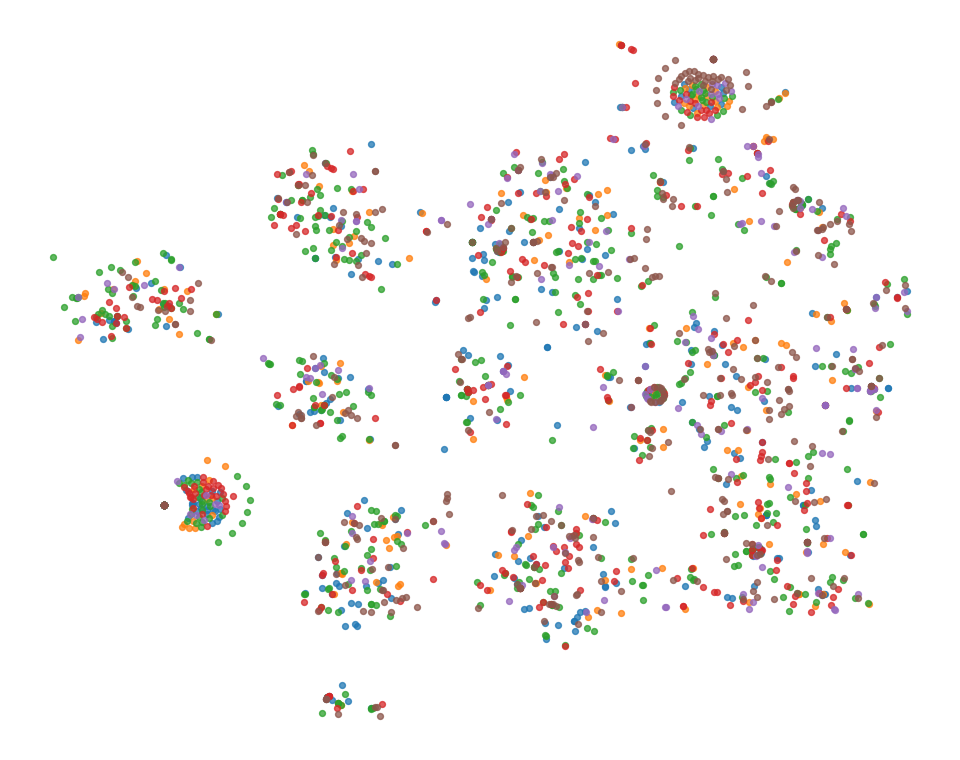

(array([[ -9.619993 ,  17.75983  ],
        [ 21.42632  ,  26.989666 ],
        [-30.565243 , -11.056436 ],
        ...,
        [-34.236534 , -14.331372 ],
        [ -1.0415422,  24.939613 ],
        [  9.144768 ,  32.31167  ]], shape=(2000, 2), dtype=float32),
 array([   28,    60,    66, ..., 41271, 41272, 41276], shape=(2000,)),
 <Figure size 1000x800 with 1 Axes>,
 <Axes: >)

In [103]:
feature_matrix_unlabeled = load_feature_matrix(
        100,
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/dblp_uniGNN_old_unlabeld_simplices_PLMSC/rerun1/dblp_uniGNN_old_unlabeld_simplices_PLMSC_freq_100_minDim_0_maxSize_12",
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/dblp_uniGNN_old_unlabeld_simplices_PLMSC/rerun1/dblp_uniGNN_old_unlabeld_simplices_PLMSC_freq_100_minDim_0_maxSize_12occMap",
)
plot_tsne(
    feature_matrix_unlabeled,
    Y,
    output_file="t-SNE-unlabeled.pdf",
    max_samples=2000,
    perplexity=30,
    mode = "unlabeled"
)

Using 2000 sampled vertices for t-SNE
SVD dimensions: 37 -> 36; explained variance: 0.997
Saved plot to t-SNE-sampled.pdf


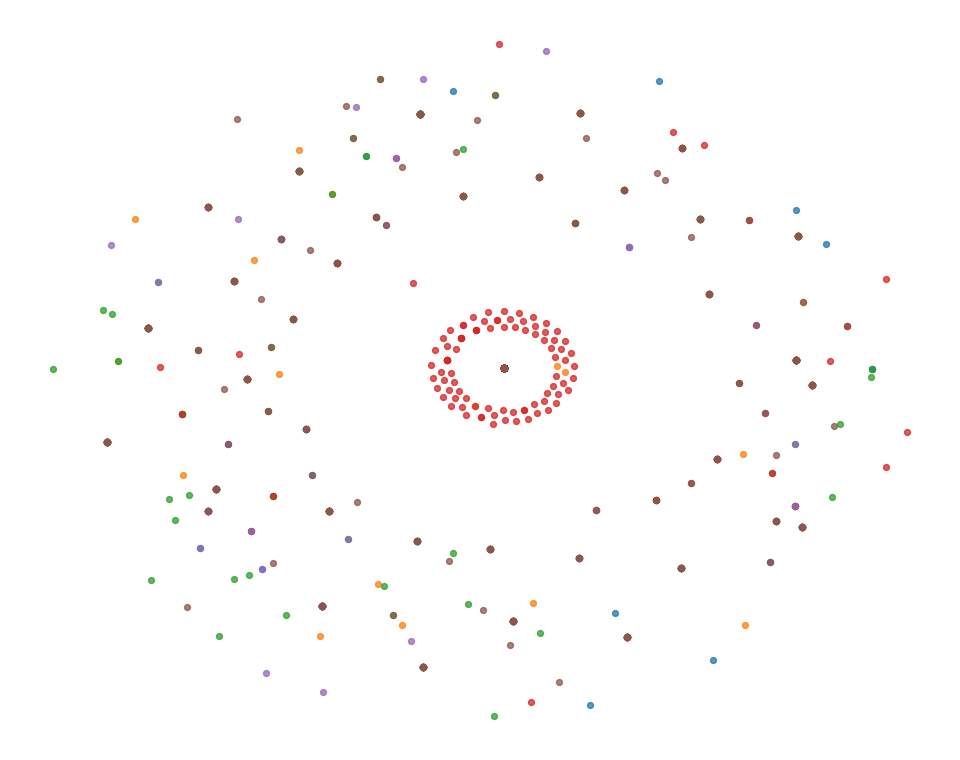

(array([[ -18.354439 ,  -15.935653 ],
        [ 148.70111  ,    9.201971 ],
        [ -21.734303 ,  -10.885381 ],
        ...,
        [   4.8513346,    5.419535 ],
        [-170.0893   ,  -35.736824 ],
        [ -72.324684 ,  -74.530754 ]], shape=(2000, 2), dtype=float32),
 array([   28,    60,    66, ..., 41271, 41272, 41276], shape=(2000,)),
 <Figure size 1000x800 with 1 Axes>,
 <Axes: >)

In [104]:
feature_matrix_sampled = load_feature_matrix(
        100,
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/AMiner_randomly_permutate_vertex_label/AMiner_randomly_permutate_vertex_label_freq_10_minDim_0_maxSize_12",
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/AMiner_randomly_permutate_vertex_label/AMiner_randomly_permutate_vertex_label_freq_10_minDim_0_maxSize_12occMap",
    )
plot_tsne(
    feature_matrix_sampled,
    Y,
    output_file="t-SNE-sampled.pdf",
    max_samples=2000,
    perplexity=30,
    mode = "shuffled-label"
)

# Extract the feature matrix

## Define training function

In [ ]:
import time


run_results, model, running_times = train_and_extract_features(
    feature_matrix_labeled,
    Y,
    G,
    args,
)

features_run_1 = run_results[0]["features"]

running_times = np.array(running_times)
print(f"The mean training time: {np.mean(running_times)}")
print(f"The std training time: {np.std(running_times)}")

number of hyperedges is 22363
Run 1/10, Total Epochs: 1000
Run 1/10, Total Epochs: 1000
Run 1/10, Total Epochs: 1000
Run 1/10, Total Epochs: 1000
UniGCNII(
  (act): ReLU()
  (input_drop): Dropout(p=0.6, inplace=False)
  (dropout): Dropout(p=0.6, inplace=False)
  (convs): ModuleList(
    (0): Linear(in_features=137, out_features=64, bias=True)
    (1-64): 64 x UniGCNIIConv(
      (W): Linear(in_features=64, out_features=64, bias=False)
    )
    (65): Linear(in_features=64, out_features=6, bias=True)
  )
)
UniGCNII(
  (act): ReLU()
  (input_drop): Dropout(p=0.6, inplace=False)
  (dropout): Dropout(p=0.6, inplace=False)
  (convs): ModuleList(
    (0): Linear(in_features=137, out_features=64, bias=True)
    (1-64): 64 x UniGCNIIConv(
      (W): Linear(in_features=64, out_features=64, bias=False)
    )
    (65): Linear(in_features=64, out_features=6, bias=True)
  )
)
UniGCNII(
  (act): ReLU()
  (input_drop): Dropout(p=0.6, inplace=False)
  (dropout): Dropout(p=0.6, inplace=False)
  (convs)

## Now testing with machine learning model

In [127]:
captured = {}

def capture_classifier_input(module, inputs):
    captured["features"] = inputs[0].detach().cpu().clone()

hook = model.convs[-1].register_forward_pre_hook(
    capture_classifier_input
)



In [141]:
feature_matrix_labeled_all_dimension = load_feature_matrix(
        150,
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_1000000000",
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_1000000000occMap",
    )
feature_matrix_labeled_12 = load_feature_matrix(
        150,
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12",
        "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12occMap",
    )
unigcnii_features_by_run = {
    result["run"]: result["features"]
    for result in run_results
}

feature_sets = {
    "Labeled simplets (12 dim)": feature_matrix_labeled_12,
    "Labeled simplets (all)": feature_matrix_labeled_all_dimension,
    "Unlabeled simplets": feature_matrix_unlabeled,
    "Shuffled-label simplets": feature_matrix_sampled,
    "UniGCNII embeddings": unigcnii_features_by_run,
}

classical_results, classical_predictions = evaluate_classical_models(
    feature_sets,
    Y,
    args,
)

classical_results.to_csv(
    "classical_feature_classifier_results.csv",
    index=False,
)

classical_summary = (
    classical_results
    .groupby(["feature_set", "classifier"], as_index=False)
    .agg(
        mean_train_accuracy=("train_accuracy", "mean"),
        std_train_accuracy=(
            "train_accuracy",
            lambda values: np.std(values, ddof=0),
        ),
        mean_test_accuracy=("test_accuracy", "mean"),
        std_test_accuracy=(
            "test_accuracy",
            lambda values: np.std(values, ddof=0),
        ),
    )
    .sort_values(["classifier", "feature_set"])
)

classical_summary


number of hyperedges is 22363
Labeled simplets (12 dim) | Logistic regression | run 1/10 | train=0.8103 | test=0.8117
Labeled simplets (12 dim) | Linear SVM | run 1/10 | train=0.8103 | test=0.8102
Labeled simplets (12 dim) | SVM | run 1/10 | train=0.8103 | test=0.7985
Labeled simplets (12 dim) | KNN | run 1/10 | train=0.8075 | test=0.8106
Labeled simplets (12 dim) | Decision tree | run 1/10 | train=0.8103 | test=0.8100
Labeled simplets (all) | Logistic regression | run 1/10 | train=0.8287 | test=0.8147
Labeled simplets (all) | Linear SVM | run 1/10 | train=0.8287 | test=0.8108
Labeled simplets (all) | SVM | run 1/10 | train=0.8287 | test=0.8047
Labeled simplets (all) | KNN | run 1/10 | train=0.8178 | test=0.8297
Labeled simplets (all) | Decision tree | run 1/10 | train=0.8287 | test=0.8081
Unlabeled simplets | Logistic regression | run 1/10 | train=0.5793 | test=0.2461
Unlabeled simplets | Linear SVM | run 1/10 | train=0.5489 | test=0.2459
Unlabeled simplets | SVM | run 1/10 | train=0.

,feature_set,classifier,mean_train_accuracy,std_train_accuracy,mean_test_accuracy,std_test_accuracy
0,Labeled simplets (12 dim),Decision tree,0.812644,0.006044,0.812118,0.002437
5,Labeled simplets (all),Decision tree,0.832931,0.003990,0.832289,0.012150
10,Shuffled-label simplets,Decision tree,0.300402,0.006573,0.184283,0.003042
15,UniGCNII embeddings,Decision tree,0.997586,0.001022,0.860879,0.006186
20,Unlabeled simplets,Decision tree,0.823678,0.009408,0.228138,0.007182
1,Labeled simplets (12 dim),KNN,0.803103,0.007494,0.807803,0.018372
6,Labeled simplets (all),KNN,0.820460,0.009517,0.820292,0.009278
11,Shuffled-label simplets,KNN,0.255747,0.015962,0.214155,0.045755
16,UniGCNII embeddings,KNN,0.997529,0.001122,0.901711,0.003790
21,Unlabeled simplets,KNN,0.810632,0.010416,0.247025,0.010527
